In [1]:
import sys
sys.path.append('..')

import pandas as pd
from entsoe import EntsoePandasClient
from config import TOKEN, AREAS, DISPLAY_TZ

print("✓ Knihovny načteny")
print(f"  Python verze: {sys.version.split()[0]}")
print(f"  Pandas verze: {pd.__version__}")

✓ Knihovny načteny
  Python verze: 3.13.12
  Pandas verze: 2.3.3


In [2]:
import sys
!{sys.executable} -m pip install entsoe-py

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\IvaRichterová\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path=r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\.env")

print(f"Token načten: {os.getenv('ENTSOE_TOKEN')}")

Token načten: 1d159fa6-095b-4397-a599-ca48afba15a9


In [4]:
from dotenv import load_dotenv
from entsoe import EntsoePandasClient
import os

load_dotenv(dotenv_path=r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\.env")
TOKEN = os.getenv("ENTSOE_TOKEN")

client = EntsoePandasClient(api_key=TOKEN)
print("✓ Klient vytvořen")

✓ Klient vytvořen


In [5]:
import pandas as pd

konec   = pd.Timestamp.now(tz="UTC").floor("h")
zacatek = konec - pd.Timedelta(days=30)

print(f"Stahuji data od: {zacatek}")
print(f"               do: {konec}")

ceny_raw = client.query_day_ahead_prices(
    country_code="10YCZ-CEPS-----N",
    start=zacatek,
    end=konec,
)

print(f"✓ Data stažena!")
print(f"  Počet hodnot: {len(ceny_raw)}")

Stahuji data od: 2026-02-18 10:00:00+00:00
               do: 2026-03-20 10:00:00+00:00
✓ Data stažena!
  Počet hodnot: 2881


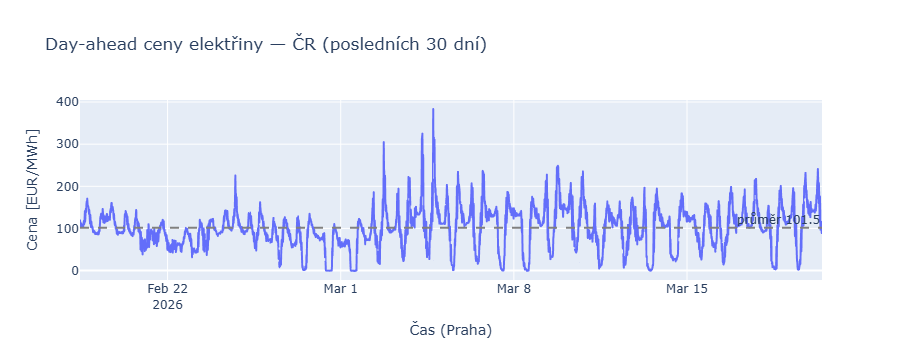

In [6]:
import plotly.express as px

ceny = ceny_raw.tz_convert("Europe/Prague")

df = ceny.reset_index()
df.columns = ["cas", "cena_eur_mwh"]

fig = px.line(
    df,
    x="cas",
    y="cena_eur_mwh",
    title="Day-ahead ceny elektřiny — ČR (posledních 30 dní)",
    labels={"cas": "Čas (Praha)", "cena_eur_mwh": "Cena [EUR/MWh]"},
)

fig.add_hline(
    y=df["cena_eur_mwh"].mean(),
    line_dash="dash",
    line_color="gray",
    annotation_text=f"průměr {df['cena_eur_mwh'].mean():.1f}",
)

fig.show()

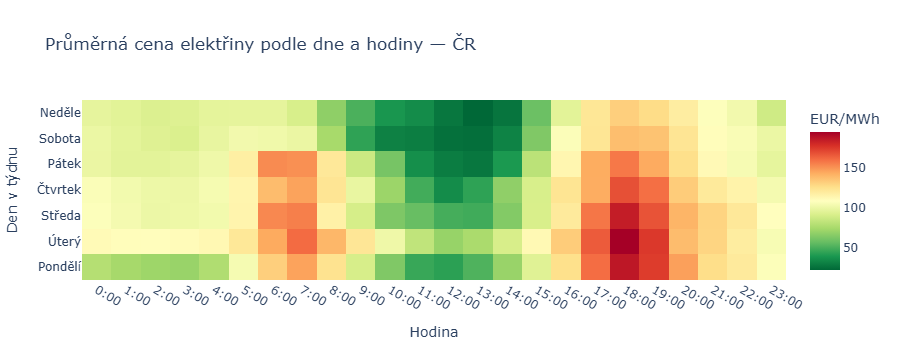

In [7]:
import plotly.graph_objects as go
import numpy as np

# Převod na Prague čas a vytvoření DataFrame
ceny = ceny_raw.tz_convert("Europe/Prague")
df = ceny.reset_index()
df.columns = ["cas", "cena"]

# Přidáme sloupce pro den v týdnu a hodinu
df["den"] = df["cas"].dt.day_name()
df["hodina"] = df["cas"].dt.hour

# Vytvoříme kontingenční tabulku - řádky = dny, sloupce = hodiny
poradi_dni = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
nazvy_dni = ["Pondělí", "Úterý", "Středa", "Čtvrtek", "Pátek", "Sobota", "Neděle"]

pivot = df.pivot_table(index="den", columns="hodina", values="cena", aggfunc="mean")
pivot = pivot.reindex(poradi_dni)

# Heatmapa
fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=[f"{h}:00" for h in range(24)],
    y=nazvy_dni,
    colorscale="RdYlGn_r",
    colorbar=dict(title="EUR/MWh"),
))

fig.update_layout(
    title="Průměrná cena elektřiny podle dne a hodiny — ČR",
    xaxis_title="Hodina",
    yaxis_title="Den v týdnu",
)

fig.show()

In [8]:
# Stáhneme ceny pro všechny země
zeme = {
    "CZ": "10YCZ-CEPS-----N",
    "DE": "10Y1001A1001A82H",
    "AT": "10YAT-APG------L",
    "SK": "10YSK-SEPS-----K",
    "PL": "10YPL-AREA-----S",
    "FR": "10YFR-RTE------C",
}

ceny_zeme = {}

for kod, eic in zeme.items():
    print(f"Stahuji {kod}...")
    try:
        data = client.query_day_ahead_prices(
            country_code=eic,
            start=zacatek,
            end=konec,
        )
        ceny_zeme[kod] = data.tz_convert("Europe/Prague")
        print(f"  ✓ {kod}: {len(data)} hodnot")
    except Exception as e:
        print(f"  ✗ {kod}: chyba — {e}")

Stahuji CZ...
  ✓ CZ: 2881 hodnot
Stahuji DE...
  ✓ DE: 2881 hodnot
Stahuji AT...
  ✓ AT: 2881 hodnot
Stahuji SK...
  ✓ SK: 2881 hodnot
Stahuji PL...
  ✓ PL: 2881 hodnot
Stahuji FR...
  ✓ FR: 2881 hodnot


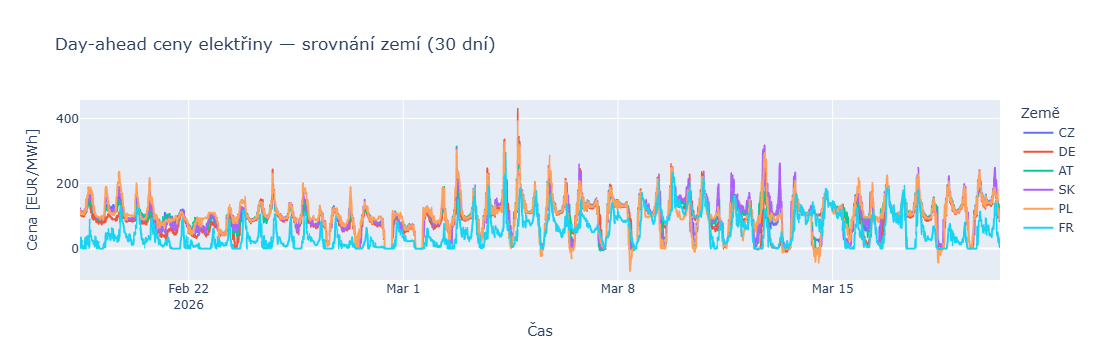

In [9]:
import pandas as pd
import plotly.express as px

# Složíme všechna data do jednoho DataFrame
df_all = pd.DataFrame(ceny_zeme)

# Graf
fig = px.line(
    df_all,
    title="Day-ahead ceny elektřiny — srovnání zemí (30 dní)",
    labels={"value": "Cena [EUR/MWh]", "index": "Čas", "variable": "Země"},
)

fig.show()

In [10]:
# Denní statistiky pro ČR
df_stats = df_all["CZ"].reset_index()
df_stats.columns = ["cas", "cena"]

df_stats["den"] = df_stats["cas"].dt.date

statistiky = df_stats.groupby("den")["cena"].agg(
    minimum="min",
    maximum="max",
    prumer="mean",
    median="median"
).round(2)

print("=== Denní statistiky cen elektřiny — ČR [EUR/MWh] ===")
print(statistiky)

=== Denní statistiky cen elektřiny — ČR [EUR/MWh] ===
            minimum  maximum  prumer  median
den                                         
2026-02-18    91.05   170.66  123.24  114.72
2026-02-19    84.96   160.61  115.47  120.21
2026-02-20    38.35   143.62   99.00   92.43
2026-02-21    46.10   120.53   82.10   83.46
2026-02-22    31.63   101.36   66.59   62.95
2026-02-23    36.77   122.81   83.13   90.79
2026-02-24    82.17   225.74  114.79  106.79
2026-02-25    47.72   162.23  101.39   95.08
2026-02-26     7.85   126.67   81.19   80.65
2026-02-27     1.16   134.80   72.49   78.74
2026-02-28    -0.48   110.53   57.56   75.71
2026-03-01    -1.03   122.72   58.60   63.44
2026-03-02    15.65   304.88  103.17   90.36
2026-03-03    22.50   222.18  107.14  100.00
2026-03-04    27.37   383.46  144.89  136.44
2026-03-05     0.92   234.23  115.16  114.63
2026-03-06    16.02   236.63  116.39  117.48
2026-03-07    -0.08   186.65  105.33  130.78
2026-03-08    -0.83   175.22   97.82  130.14
2

In [11]:
import os
import pandas as pd
from datetime import datetime, timedelta

zeme = {
    "CZ": "10YCZ-CEPS-----N",
    "DE": "10Y1001A1001A82H",
    "AT": "10YAT-APG------L",
    "SK": "10YSK-SEPS-----K",
    "PL": "10YPL-AREA-----S",
    "FR": "10YFR-RTE------C",
}

ceny_zeme = {}
cache_slozka = r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\data\cache"

for kod in zeme:
    soubor_parquet = os.path.join(cache_slozka, f"ceny_{kod}.parquet")
    soubor_csv = os.path.join(cache_slozka, f"ceny_{kod}.csv")

    if os.path.exists(soubor_parquet):
        stari = datetime.now() - datetime.fromtimestamp(os.path.getmtime(soubor_parquet))
        if stari < timedelta(hours=24):
            print(f"  ✓ {kod}: načteno z cache")
            ceny_zeme[kod] = pd.read_parquet(soubor_parquet).iloc[:, 0]
            continue

    print(f"  Stahuji {kod} z API...")
    try:
        data = client.query_day_ahead_prices(
            country_code=zeme[kod],
            start=zacatek,
            end=konec,
        )
        ceny_zeme[kod] = data.tz_convert("Europe/Prague")
        # Uložení do obou formátů
        ceny_zeme[kod].to_frame().to_parquet(soubor_parquet)
        ceny_zeme[kod].to_csv(soubor_csv)
        print(f"  ✓ {kod}: staženo a uloženo")
    except Exception as e:
        print(f"  ✗ {kod}: chyba — {e}")

  ✓ CZ: načteno z cache
  ✓ DE: načteno z cache
  ✓ AT: načteno z cache
  ✓ SK: načteno z cache
  ✓ PL: načteno z cache
  ✓ FR: načteno z cache


In [12]:
import sys
!{sys.executable} -m pip install kaleido

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\IvaRichterová\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import os

export_slozka = r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\exports"
os.makedirs(export_slozka, exist_ok=True)

# Graf ceny ČR
fig.write_image(os.path.join(export_slozka, "01_ceny_cr_30dni.png"), width=1200, height=600)
fig.write_html(os.path.join(export_slozka, "01_ceny_cr_30dni.html"))

# Heatmapa
fig_heatmapa = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=[f"{h}:00" for h in range(24)],
    y=nazvy_dni,
    colorscale="RdYlGn_r",
    colorbar=dict(title="EUR/MWh"),
))
fig_heatmapa.update_layout(title="Průměrná cena elektřiny podle dne a hodiny — ČR")
fig_heatmapa.write_image(os.path.join(export_slozka, "01_heatmapa.png"), width=1200, height=600)
fig_heatmapa.write_html(os.path.join(export_slozka, "01_heatmapa.html"))

print("✓ Exporty notebooku 01 uloženy")

✓ Exporty notebooku 01 uloženy
